# Mask2Former Swin-B (ADE20K) -> NYU Full Fine-Tuning

This notebook loads **Mask2Former with a Swin-Base backbone** pretrained on **ADE20K**, prepares NYU semantic segmentation data, and runs a **full training loop** with periodic evaluation and checkpointing.

Goal: complete a reproducible fine-tuning workflow for full NYU training (not smoke mode).

## 1) Set Up Environment and Install Dependencies

In [2]:
import os
import sys
import subprocess
from pathlib import Path

ROOT = Path('/home/abdou/Projects/Python/RTSGS').resolve()
M2F_ROOT = ROOT / 'Mask2Former'
assert M2F_ROOT.exists(), f'Mask2Former repo not found at {M2F_ROOT}'

os.chdir(ROOT)
print('Workspace root:', ROOT)
print('Mask2Former root:', M2F_ROOT)

def pip_install_if_missing(pkg_import_name: str, pip_name: str | None = None):
    pip_name = pip_name or pkg_import_name
    try:
        __import__(pkg_import_name)
        print(f'[OK] {pkg_import_name} already available')
    except Exception:
        print(f'[INSTALL] {pip_name}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

# Lightweight helpers for NYU .mat loading and visualization.
pip_install_if_missing('h5py')
pip_install_if_missing('scipy')
pip_install_if_missing('matplotlib')
pip_install_if_missing('PIL', 'Pillow')

# Ensure local Mask2Former code is importable.
if str(M2F_ROOT) not in sys.path:
    sys.path.insert(0, str(M2F_ROOT))

print('Python executable:', sys.executable)

Workspace root: /home/abdou/Projects/Python/RTSGS
Mask2Former root: /home/abdou/Projects/Python/RTSGS/Mask2Former
[OK] h5py already available
[OK] scipy already available
[OK] matplotlib already available
[OK] PIL already available
Python executable: /home/abdou/Programs/miniconda3/envs/rtsgs_mask2former_nb/bin/python


In [3]:
import random
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_train_loader
from detectron2.data.datasets import load_sem_seg
from detectron2.utils.visualizer import Visualizer
from detectron2.engine import default_setup
from detectron2.projects.deeplab import add_deeplab_config

from mask2former import add_maskformer2_config, MaskFormerSemanticDatasetMapper
from train_net import Trainer

# 2) Reproducibility settings.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', DEVICE)

/home/abdou/Programs/miniconda3/envs/rtsgs_mask2former_nb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/abdou/Programs/miniconda3/envs/rtsgs_mask2former_nb/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/abdou/Projects/Python/RTSGS/Mask2Former/mask2former/modeling/pixel_decoder/msdeformattn.py:314: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


Torch: 2.5.1+cu121
CUDA available: True
Device: cuda


## 3) Register NYU Dataset in Detectron2 Format (Full Split)

In [4]:
import csv
import h5py
from scipy.io import loadmat

NYU_MAT = ROOT / 'SceneGraph' / 'nyu_depth_v2_labeled.mat'
assert NYU_MAT.exists(), f'NYU mat file missing: {NYU_MAT}'

SCANNET_TSV = ROOT / 'SceneGraph' / 'scannet-labels.combined.tsv'
assert SCANNET_TSV.exists(), f'Mapping TSV missing: {SCANNET_TSV}'

NYU_EXPORT = ROOT / 'SceneGraph' / 'nyu_semseg_full'
IMG_TR = NYU_EXPORT / 'images' / 'train'
LBL_TR = NYU_EXPORT / 'labels' / 'train'
IMG_VA = NYU_EXPORT / 'images' / 'val'
LBL_VA = NYU_EXPORT / 'labels' / 'val'
for p in [IMG_TR, LBL_TR, IMG_VA, LBL_VA]:
    p.mkdir(parents=True, exist_ok=True)

def _to_nhwc_images(arr: np.ndarray):
    # Normalize possible NYU layouts into (N, H, W, 3).
    if arr.ndim != 4:
        raise ValueError(f'Expected 4D image tensor, got {arr.shape}')
    if arr.shape[-1] == 3:
        return arr
    if arr.shape[1] == 3:
        return np.transpose(arr, (0, 2, 3, 1))
    if arr.shape[0] == 3:
        return np.transpose(arr, (3, 1, 2, 0))
    if arr.shape[2] == 3:
        return np.transpose(arr, (3, 0, 1, 2))
    raise ValueError(f'Could not infer channel axis for image tensor shape {arr.shape}')

def _to_nhw_labels(arr: np.ndarray, n: int):
    # Normalize labels into (N, H, W).
    if arr.ndim != 3:
        raise ValueError(f'Expected 3D tensor, got {arr.shape}')
    if arr.shape[0] == n:
        return arr
    if arr.shape[-1] == n:
        return np.transpose(arr, (2, 0, 1))
    for axis in range(3):
        if arr.shape[axis] == n:
            order = [axis] + [i for i in range(3) if i != axis]
            return np.transpose(arr, tuple(order))
    raise ValueError(f'Could not align tensor shape {arr.shape} with N={n}')

def _decode_matlab_char_array(arr: np.ndarray):
    flat = arr.flatten()
    return ''.join(chr(int(x)) for x in flat if int(x) != 0)

def _decode_names_from_scipy(names_obj):
    # names is usually a MATLAB cell array when loaded with scipy.io.loadmat.
    decoded = []
    arr = np.asarray(names_obj).squeeze()
    for item in arr:
        if isinstance(item, np.ndarray):
            chars = item.squeeze()
            if chars.dtype.kind in ('U', 'S'):
                name = ''.join(chars.tolist()).strip()
            else:
                name = ''.join(chr(int(x)) for x in chars.flatten() if int(x) != 0)
        else:
            name = str(item).strip()
        decoded.append(name)
    return decoded

def _load_nyu_labeled(mat_path: Path):
    # Official NYU semantic labels are in `labels`; `instances` are instance IDs.
    # See: https://cs.nyu.edu/~fergus/datasets/nyu_depth_v2.html
    try:
        with h5py.File(mat_path, 'r') as f:
            imgs = _to_nhwc_images(np.array(f['images']))
            labels = _to_nhw_labels(np.array(f['labels']), imgs.shape[0])
            instances = _to_nhw_labels(np.array(f['instances']), imgs.shape[0]) if 'instances' in f else None

            names = None
            if 'names' in f:
                names_ds = f['names']
                decoded = []
                for i in range(names_ds.shape[1]):
                    ref = names_ds[0, i]
                    decoded.append(_decode_matlab_char_array(np.array(f[ref])).strip())
                names = decoded
            return imgs, labels, instances, names
    except Exception:
        mat = loadmat(mat_path)
        imgs = _to_nhwc_images(np.array(mat['images']))
        labels = _to_nhw_labels(np.array(mat['labels']), imgs.shape[0])
        instances = _to_nhw_labels(np.array(mat['instances']), imgs.shape[0]) if 'instances' in mat else None
        names = _decode_names_from_scipy(mat['names']) if 'names' in mat else None
        return imgs, labels, instances, names

def normalize_orientation(rgb: np.ndarray, sem: np.ndarray):
    # NYU RGB-D frames are expected in landscape orientation (H <= W).
    if rgb.shape[0] > rgb.shape[1]:
        rgb = np.transpose(rgb, (1, 0, 2))
        sem = np.transpose(sem, (1, 0))
    return rgb, sem

def _parse_int(value: str):
    v = (value or '').strip()
    if not v:
        return None
    try:
        return int(v)
    except Exception:
        return None

imgs, sem_raw, inst_raw, names_all = _load_nyu_labeled(NYU_MAT)
print('NYU images raw shape:', imgs.shape)
print('NYU labels raw shape:', sem_raw.shape)
if inst_raw is not None:
    print('NYU instances raw shape:', inst_raw.shape)

raw_unique = np.unique(sem_raw.astype(np.int32))
print('Raw label ids present (first 60):', raw_unique[:60], '... count', len(raw_unique))
print('Raw label min/max:', int(raw_unique.min()), int(raw_unique.max()))

# Read ScanNet TSV mapping NYU id -> NYU40 id.
nyu_to_nyu40 = {}
nyu40_names = {}
with open(SCANNET_TSV, 'r', newline='', encoding='utf-8', errors='replace') as f:
    reader = csv.DictReader(f, delimiter='\t')
    for row in reader:
        nyu_id = _parse_int(row.get('nyuId', ''))
        nyu40_id = _parse_int(row.get('nyu40id', ''))
        if nyu40_id is None or nyu40_id < 1 or nyu40_id > 40:
            continue
        if nyu_id is not None and nyu_id > 0:
            nyu_to_nyu40[nyu_id] = nyu40_id
        cname = (row.get('nyu40class') or '').strip()
        if cname and nyu40_id not in nyu40_names:
            nyu40_names[nyu40_id] = cname

assert len(nyu_to_nyu40) > 0, 'No valid NYU->NYU40 mappings parsed from TSV.'

# Fixed NYU40 training space: contiguous ids [0..39] correspond to nyu40 ids [1..40].
num_classes = 40
class_names = [nyu40_names.get(i, f'nyu40_{i:02d}') for i in range(1, 41)]
IGNORE_LABEL = 255
LABEL_DTYPE = np.uint8

print('Using semantic source: labels + scannet-labels.combined.tsv (NYU->NYU40)')
print('Parsed NYU->NYU40 pairs:', len(nyu_to_nyu40))
print('Num classes:', num_classes)
print('Ignore label value:', IGNORE_LABEL)
print('Label dtype:', LABEL_DTYPE)

max_raw_id = int(raw_unique.max())
lut = np.full(max_raw_id + 1, IGNORE_LABEL, dtype=np.int32)
for nyu_id, nyu40_id in nyu_to_nyu40.items():
    if 0 <= nyu_id <= max_raw_id:
        lut[nyu_id] = nyu40_id - 1

NUM_TOTAL = int(imgs.shape[0])
VAL_RATIO = 0.1
MAX_EXPORT_SAMPLES = None  # Full-data mode.

indices = np.arange(NUM_TOTAL)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

if MAX_EXPORT_SAMPLES is not None:
    indices = indices[:MAX_EXPORT_SAMPLES]

num_val = max(1, int(len(indices) * VAL_RATIO))
num_train = len(indices) - num_val
train_indices = indices[:num_train]
val_indices = indices[num_train:]

print('Split sizes -> train:', len(train_indices), 'val:', len(val_indices))

# Clear old exported files to keep dataset directory consistent.
for p in [IMG_TR, LBL_TR, IMG_VA, LBL_VA]:
    for fp in p.glob('*'):
        fp.unlink()

def sem_to_train_label(sem2d: np.ndarray):
    # Remap raw NYU labels into NYU40 contiguous ids [0..39].
    x = sem2d.astype(np.int32)
    out = np.full(x.shape, IGNORE_LABEL, dtype=LABEL_DTYPE)
    in_range = (x >= 0) & (x <= max_raw_id)
    mapped = np.full(x.shape, IGNORE_LABEL, dtype=np.int32)
    mapped[in_range] = lut[x[in_range]]
    valid = mapped != IGNORE_LABEL
    out[valid] = mapped[valid].astype(LABEL_DTYPE)
    return out

def export_sample(src_idx: int, split: str, out_idx: int):
    rgb = imgs[src_idx]
    sem = sem_raw[src_idx]
    rgb, sem = normalize_orientation(rgb, sem)
    lbl = sem_to_train_label(sem)

    if rgb.dtype != np.uint8:
        rgb = np.clip(rgb, 0, 255).astype(np.uint8)

    img_name = f'nyu_{out_idx:06d}.jpg'
    lbl_name = f'nyu_{out_idx:06d}.png'

    if split == 'train':
        Image.fromarray(rgb).save(IMG_TR / img_name)
        Image.fromarray(lbl).save(LBL_TR / lbl_name)
    else:
        Image.fromarray(rgb).save(IMG_VA / img_name)
        Image.fromarray(lbl).save(LBL_VA / lbl_name)

for out_idx, src_idx in enumerate(train_indices):
    export_sample(int(src_idx), 'train', out_idx)
for out_idx, src_idx in enumerate(val_indices):
    export_sample(int(src_idx), 'val', out_idx)

sample_rgb = np.array(Image.open(sorted(IMG_TR.glob('*.jpg'))[0]))
sample_lbl = np.array(Image.open(sorted(LBL_TR.glob('*.png'))[0]))
print('Exported train images:', len(list(IMG_TR.glob('*.jpg'))))
print('Exported val images:', len(list(IMG_VA.glob('*.jpg'))))
print('Example exported image shape:', sample_rgb.shape)
print('Example label dtype:', sample_lbl.dtype, 'min:', int(sample_lbl.min()), 'max:', int(sample_lbl.max()))

# Label quality diagnostics after remap.
label_paths = sorted(LBL_TR.glob('*.png'))
sample_count = min(64, len(label_paths))
if sample_count > 0:
    all_train_lbl = np.concatenate([
        np.array(Image.open(p)).reshape(-1)
        for p in label_paths[:sample_count]
    ], axis=0)
    ignore_ratio = float((all_train_lbl == IGNORE_LABEL).mean())
    present_ids = np.unique(all_train_lbl[all_train_lbl != IGNORE_LABEL]).astype(np.int32)
    present_names = [class_names[int(i)] for i in present_ids if int(i) < num_classes]
    print(f'Ignore-label ratio (sampled train labels): {ignore_ratio:.4f}')
    print('Present NYU40 class ids in sampled labels:', present_ids[:50], 'count', len(present_ids))
    print('Present NYU40 class names (sampled):', present_names[:20])

train_name = 'nyu_sem_seg_train_full'
val_name = 'nyu_sem_seg_val_full'
for name in [train_name, val_name]:
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)

DatasetCatalog.register(
    train_name,
    lambda: load_sem_seg(str(LBL_TR), str(IMG_TR), gt_ext='png', image_ext='jpg'),
)
DatasetCatalog.register(
    val_name,
    lambda: load_sem_seg(str(LBL_VA), str(IMG_VA), gt_ext='png', image_ext='jpg'),
)

for name in [train_name, val_name]:
    MetadataCatalog.get(name).set(
        thing_classes=[],
        stuff_classes=class_names,
        stuff_dataset_id_to_contiguous_id={i: i for i in range(num_classes)},
        ignore_label=IGNORE_LABEL,
        evaluator_type='sem_seg',
    )

train_records = DatasetCatalog.get(train_name)
val_records = DatasetCatalog.get(val_name)
print('Registered train records:', len(train_records))
print('Registered val records:', len(val_records))
print('Configured classes:', num_classes)
print('Sample record keys:', train_records[0].keys())

NYU images raw shape: (1449, 640, 480, 3)
NYU labels raw shape: (1449, 640, 480)
NYU instances raw shape: (1449, 640, 480)
Raw label ids present (first 60): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59] ... count 895
Raw label min/max: 0 894
Using semantic source: labels + scannet-labels.combined.tsv (NYU->NYU40)
Parsed NYU->NYU40 pairs: 264
Num classes: 40
Ignore label value: 255
Label dtype: <class 'numpy.uint8'>
Split sizes -> train: 1305 val: 144
Exported train images: 1305
Exported val images: 144
Example exported image shape: (480, 640, 3)
Example label dtype: uint8 min: 0 max: 255
Ignore-label ratio (sampled train labels): 0.2057
Present NYU40 class ids in sampled labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 30 31 32 33 34 35 36 37 38 39] count 39
Present NYU40 class names (sampled): ['wall',

Sample source index: 1441
Old mapping classes present (excluding ignore): 9
New NYU40 classes present (excluding ignore): 8


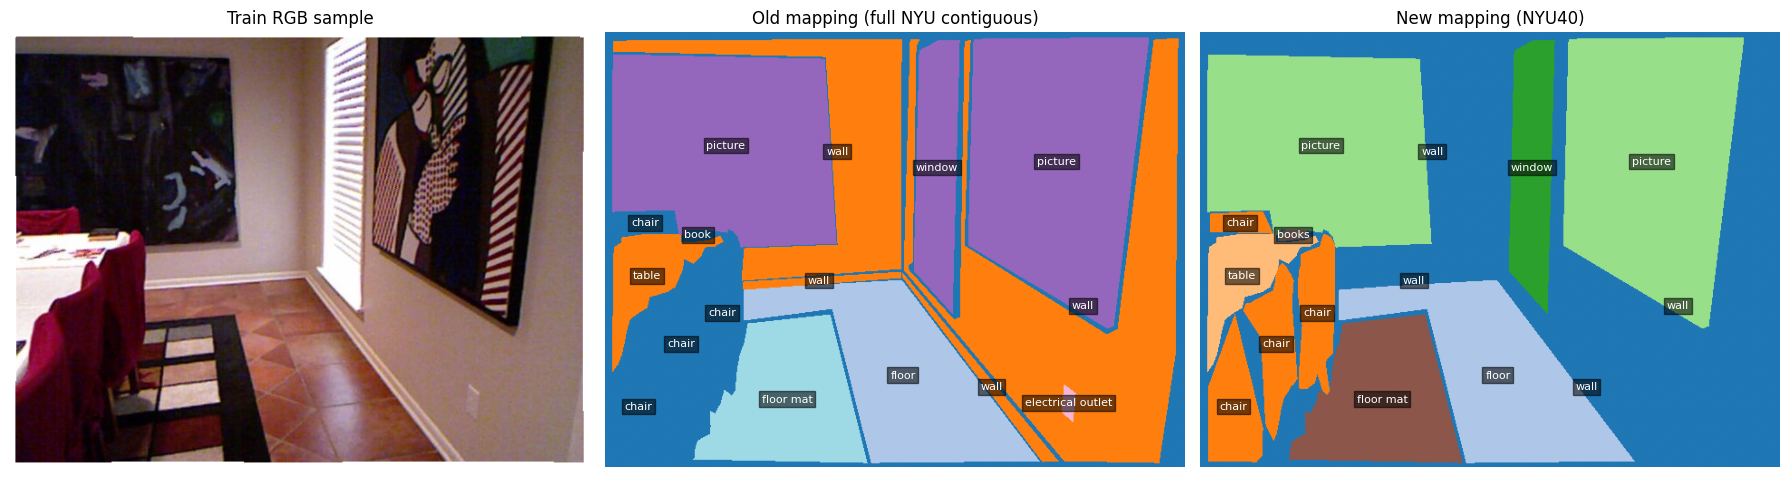

In [5]:
# 3.5) Visualize one train sample: old mapping vs new NYU40 mapping
# Old mapping = contiguous IDs from full NYU labels (1..894 -> 0..893)
# New mapping = nyuId -> nyu40id from scannet-labels.combined.tsv (1..40 -> 0..39)

from scipy import ndimage as ndi

sample_src_idx = int(train_indices[0])
rgb = imgs[sample_src_idx]
sem = sem_raw[sample_src_idx]
rgb, sem = normalize_orientation(rgb, sem)

# Rebuild old full-label mapping (used before NYU40 remap).
old_valid_raw_ids = sorted(int(x) for x in raw_unique.tolist() if int(x) > 0)
old_max_raw = max(old_valid_raw_ids)
old_ignore = 65535 if len(old_valid_raw_ids) > 255 else 255
old_dtype = np.uint16 if len(old_valid_raw_ids) > 255 else np.uint8
old_lut = np.full(old_max_raw + 1, old_ignore, dtype=np.int32)
for cid, rid in enumerate(old_valid_raw_ids):
    old_lut[rid] = cid

x = sem.astype(np.int32)
old_lbl = np.full(x.shape, old_ignore, dtype=old_dtype)
old_in_range = (x >= 0) & (x <= old_max_raw)
old_mapped = np.full(x.shape, old_ignore, dtype=np.int32)
old_mapped[old_in_range] = old_lut[x[old_in_range]]
old_valid = old_mapped != old_ignore
old_lbl[old_valid] = old_mapped[old_valid].astype(old_dtype)

# New NYU40 mapping from current pipeline.
new_lbl = sem_to_train_label(sem)

# Prepare views for plotting (replace ignore with -1 so ignored regions are visible in a fixed color).
old_view = old_lbl.astype(np.int32)
old_view[old_view == old_ignore] = -1
new_view = new_lbl.astype(np.int32)
new_view[new_view == IGNORE_LABEL] = -1

print('Sample source index:', sample_src_idx)
print('Old mapping classes present (excluding ignore):', len(np.unique(old_view[old_view >= 0])))
print('New NYU40 classes present (excluding ignore):', len(np.unique(new_view[new_view >= 0])))

def _old_name_from_raw_id(raw_id: int) -> str:
    if isinstance(names_all, (list, tuple)) and raw_id > 0 and raw_id <= len(names_all):
        name = str(names_all[raw_id - 1]).strip()
        if name:
            return name
    return f'raw_{raw_id}'

def _annotate_segments(ax, label_map: np.ndarray, id_to_name: dict[int, str], min_area: int = 120):
    # Annotate each connected component with its class name near its centroid.
    ids = np.unique(label_map[label_map >= 0]).astype(np.int32)
    for cid in ids:
        mask = (label_map == int(cid))
        cc, ncc = ndi.label(mask)
        if ncc == 0:
            continue
        for cc_id in range(1, ncc + 1):
            comp = (cc == cc_id)
            area = int(comp.sum())
            if area < min_area:
                continue
            ys, xs = np.where(comp)
            y = float(np.mean(ys))
            x = float(np.mean(xs))
            ax.text(
                x, y, id_to_name.get(int(cid), f'id_{int(cid)}'),
                fontsize=8,
                color='white',
                ha='center',
                va='center',
                bbox=dict(facecolor='black', alpha=0.55, pad=2),
            )

old_name_map = {}
for cid in np.unique(old_view[old_view >= 0]).astype(np.int32):
    raw_id = old_valid_raw_ids[int(cid)]
    old_name_map[int(cid)] = _old_name_from_raw_id(int(raw_id))

new_name_map = {}
for nid in np.unique(new_view[new_view >= 0]).astype(np.int32):
    new_name_map[int(nid)] = class_names[int(nid)] if int(nid) < len(class_names) else f'nyu40_{int(nid):02d}'

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(rgb)
ax[0].set_title('Train RGB sample')
ax[0].axis('off')

ax[1].imshow(old_view, cmap='tab20', vmin=-1)
ax[1].set_title('Old mapping (full NYU contiguous)')
ax[1].axis('off')
_annotate_segments(ax[1], old_view, old_name_map)

ax[2].imshow(new_view, cmap='tab20', vmin=-1, vmax=39)
ax[2].set_title('New mapping (NYU40)')
ax[2].axis('off')
_annotate_segments(ax[2], new_view, new_name_map)

plt.tight_layout()
plt.show()

## 4) Load Mask2Former Swin-Base ADE20K Configuration and Weights

In [6]:
from math import ceil
from detectron2.data import build_detection_test_loader

cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

config_file = M2F_ROOT / 'configs' / 'ade20k' / 'semantic-segmentation' / 'swin' / 'maskformer2_swin_base_384_bs16_160k_res640.yaml'
assert config_file.exists(), f'Config not found: {config_file}'
cfg.merge_from_file(str(config_file))

# ADE20K pretrained Mask2Former Swin-B weights.
cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/ade20k/semantic/maskformer2_swin_base_384_bs16_160k_res640/model_final_503e96.pkl'

cfg.DATASETS.TRAIN = (train_name,)
cfg.DATASETS.TEST = (val_name,)

# Keep low-VRAM-safe settings while training on full dataset.
cfg.DATALOADER.NUM_WORKERS = 0
cfg.SOLVER.IMS_PER_BATCH = 4
# Head-only training can use a higher LR than full-model fine-tuning.
cfg.SOLVER.BASE_LR = 5e-5
cfg.SOLVER.WARMUP_ITERS = 100
cfg.SOLVER.AMP.ENABLED = True

# Force GPU training; fail fast instead of silently falling back to CPU.
assert torch.cuda.is_available(), 'CUDA is not available. Fix GPU/runtime before training.'
cfg.MODEL.SEM_SEG_HEAD.NUM_CLASSES = num_classes
cfg.MODEL.MASK_FORMER.NUM_OBJECT_QUERIES = 100
cfg.MODEL.MASK_FORMER.DEEP_SUPERVISION = False
# CE-only optimization: disable mask and dice contributions in total loss.
cfg.MODEL.MASK_FORMER.MASK_WEIGHT = 0.0
cfg.MODEL.MASK_FORMER.DICE_WEIGHT = 0.0
cfg.MODEL.DEVICE = 'cuda'

# OOM-safe image sizes for 6GB GPUs.
cfg.INPUT.MIN_SIZE_TRAIN = (256, 320)
cfg.INPUT.MAX_SIZE_TRAIN = 320
cfg.INPUT.MIN_SIZE_TEST = 320
cfg.INPUT.MAX_SIZE_TEST = 320
cfg.INPUT.CROP.ENABLED = False
cfg.INPUT.SIZE_DIVISIBILITY = 32

if hasattr(cfg.MODEL, 'SWIN') and hasattr(cfg.MODEL.SWIN, 'USE_CHECKPOINT'):
    cfg.MODEL.SWIN.USE_CHECKPOINT = False

# Full-data schedule in epochs.
num_train_samples = len(DatasetCatalog.get(train_name))
steps_per_epoch = ceil(num_train_samples / cfg.SOLVER.IMS_PER_BATCH)
NUM_EPOCHS = 50
cfg.SOLVER.MAX_ITER = steps_per_epoch * NUM_EPOCHS
cfg.SOLVER.STEPS = (int(cfg.SOLVER.MAX_ITER * 0.7), int(cfg.SOLVER.MAX_ITER * 0.9))
cfg.SOLVER.CHECKPOINT_PERIOD = steps_per_epoch
cfg.TEST.EVAL_PERIOD = steps_per_epoch

cfg.OUTPUT_DIR = str(ROOT / 'outputs' / 'mask2former_swinb_ade20k_to_nyu_full')
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Build one train batch to verify mapper/tensors.
mapper = MaskFormerSemanticDatasetMapper(cfg, is_train=True)
train_loader = build_detection_train_loader(cfg, mapper=mapper)
batch = next(iter(train_loader))

print('Config:', config_file)
print('Weights:', cfg.MODEL.WEIGHTS)
print('Output dir:', cfg.OUTPUT_DIR)
print('Train samples:', num_train_samples)
print('Steps/epoch:', steps_per_epoch)
print('Planned epochs:', NUM_EPOCHS)
print('Max iter (full):', cfg.SOLVER.MAX_ITER)
print('Eval period (iters):', cfg.TEST.EVAL_PERIOD)
print('Checkpoint period (iters):', cfg.SOLVER.CHECKPOINT_PERIOD)
print('Batch size (records):', len(batch))
print('Image tensor shape:', tuple(batch[0]['image'].shape))
print('Sem seg shape:', tuple(batch[0]['sem_seg'].shape))
print('Training device forced to:', cfg.MODEL.DEVICE)
print('Loss weights -> class:', cfg.MODEL.MASK_FORMER.CLASS_WEIGHT,
      'mask:', cfg.MODEL.MASK_FORMER.MASK_WEIGHT,
      'dice:', cfg.MODEL.MASK_FORMER.DICE_WEIGHT)
print('Swin activation checkpointing:', getattr(getattr(cfg.MODEL, 'SWIN', {}), 'USE_CHECKPOINT', 'n/a'))

Loading config /home/abdou/Projects/Python/RTSGS/Mask2Former/configs/ade20k/semantic-segmentation/swin/maskformer2_swin_base_384_bs16_160k_res640.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.
Loading config /home/abdou/Projects/Python/RTSGS/Mask2Former/configs/ade20k/semantic-segmentation/swin/../Base-ADE20K-SemanticSegmentation.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Config: /home/abdou/Projects/Python/RTSGS/Mask2Former/configs/ade20k/semantic-segmentation/swin/maskformer2_swin_base_384_bs16_160k_res640.yaml
Weights: https://dl.fbaipublicfiles.com/maskformer/mask2former/ade20k/semantic/maskformer2_swin_base_384_bs16_160k_res640/model_final_503e96.pkl
Output dir: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_swinb_ade20k_to_nyu_full
Train samples: 1305
Steps/epoch: 327
Planned epochs: 50
Max iter (full): 16350
Eval period (iters): 327
Checkpoint period (iters): 327
Batch size (records): 4
Image tensor shape: (3, 32, 32)
Sem seg shape: (32, 32)
Training device forced to: cuda
Loss weights -> class: 2.0 mask: 0.0 dice: 0.0
Swin activation checkpointing: False


## 8.5) Verify ADE20K Pretrained Weights with a Pre-Train Forward Pass

Loading config /home/abdou/Projects/Python/RTSGS/Mask2Former/configs/ade20k/semantic-segmentation/swin/maskformer2_swin_base_384_bs16_160k_res640.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.
Loading config /home/abdou/Projects/Python/RTSGS/Mask2Former/configs/ade20k/semantic-segmentation/swin/../Base-ADE20K-SemanticSegmentation.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


/home/abdou/Programs/miniconda3/envs/rtsgs_mask2former_nb/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Skip loading parameter 'sem_seg_head.predictor.class_embed.weight' to the model due to incompatible shapes: (151, 256) in the checkpoint but (41, 256) in the model! You might want to double check if this is expected.
Skip loading parameter 'sem_seg_head.predictor.class_embed.bias' to the model due to incompatible shapes: (151,) in the checkpoint but (41,) in the model! You might want to double check if this is expected.
Skip loading parameter 'criterion.empty_weight' to the model due to incompatible shap

Pretrain source: https://dl.fbaipublicfiles.com/maskformer/mask2former/ade20k/semantic/maskformer2_swin_base_384_bs16_160k_res640/model_final_503e96.pkl
Missing keys count: 0
Unexpected keys count: 0
Has incompatible sem-seg head shapes (expected when NUM_CLASSES differs): False
Forward-pass image: nyu_000000.jpg
Output keys: ['sem_seg']
sem_seg logits shape: (40, 480, 640)
pred labels sample: [ 0  1 12 17 19 20 23 24 29 38]


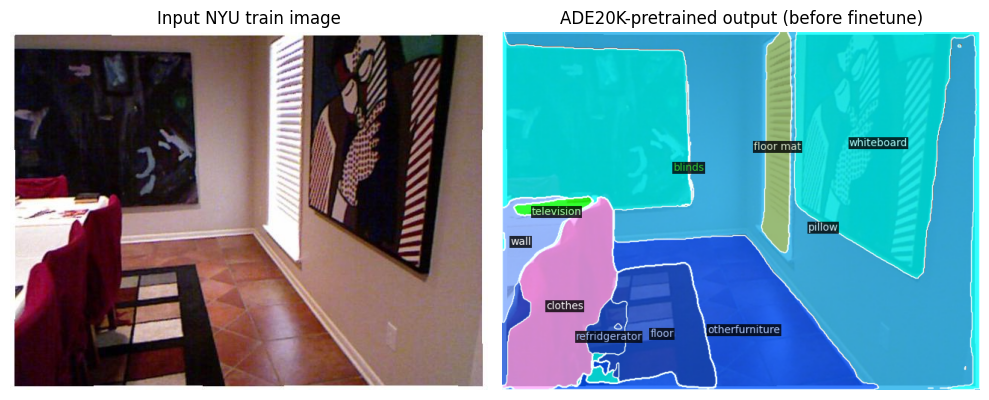

In [7]:
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.modeling import build_model
from detectron2.data import transforms as T
from detectron2.data import detection_utils as utils

# Build a fresh model using ADE20K-pretrained initialization (before any NYU fine-tuning).
cfg_pre = get_cfg()
add_deeplab_config(cfg_pre)
add_maskformer2_config(cfg_pre)
cfg_pre.merge_from_file(str(config_file))
cfg_pre.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/ade20k/semantic/maskformer2_swin_base_384_bs16_160k_res640/model_final_503e96.pkl'
cfg_pre.MODEL.SEM_SEG_HEAD.NUM_CLASSES = num_classes
cfg_pre.MODEL.DEVICE = cfg.MODEL.DEVICE
cfg_pre.INPUT.CROP.ENABLED = False
cfg_pre.INPUT.MIN_SIZE_TEST = cfg.INPUT.MIN_SIZE_TEST
cfg_pre.INPUT.MAX_SIZE_TEST = cfg.INPUT.MAX_SIZE_TEST

model_pre = build_model(cfg_pre)
model_pre.eval()
load_info = DetectionCheckpointer(model_pre).load(cfg_pre.MODEL.WEIGHTS)

print('Pretrain source:', cfg_pre.MODEL.WEIGHTS)
print('Missing keys count:', len(load_info.get('missing_keys', [])))
print('Unexpected keys count:', len(load_info.get('unexpected_keys', [])))
print('Has incompatible sem-seg head shapes (expected when NUM_CLASSES differs):',
      any('sem_seg_head.predictor.class_embed' in k for k in load_info.get('missing_keys', [])) or
      any('sem_seg_head.predictor.class_embed' in k for k in load_info.get('unexpected_keys', [])))

# Forward pass on one NYU training image before fine-tuning.
train_img_path = sorted(IMG_TR.glob('*.jpg'))[0]
raw_img = utils.read_image(str(train_img_path), format=cfg_pre.INPUT.FORMAT)
h, w = raw_img.shape[:2]

aug = T.ResizeShortestEdge(
    [cfg_pre.INPUT.MIN_SIZE_TEST, cfg_pre.INPUT.MIN_SIZE_TEST],
    cfg_pre.INPUT.MAX_SIZE_TEST,
    'choice',
)
img_resized = aug.get_transform(raw_img).apply_image(raw_img)
img_tensor = torch.as_tensor(img_resized.astype('float32').transpose(2, 0, 1))

with torch.no_grad():
    out = model_pre([{'image': img_tensor, 'height': h, 'width': w}])[0]

print('Forward-pass image:', train_img_path.name)
print('Output keys:', list(out.keys()))
if 'sem_seg' in out:
    print('sem_seg logits shape:', tuple(out['sem_seg'].shape))
    print('pred labels sample:', torch.unique(out['sem_seg'].argmax(dim=0))[:20].cpu().numpy())

# Visual sanity plot for the pre-trained model prediction.
pred = out['sem_seg'].argmax(dim=0).cpu().numpy().astype(np.uint8)
vis = Visualizer(raw_img[:, :, ::-1], metadata=MetadataCatalog.get(train_name), scale=1.0)
vis_img = vis.draw_sem_seg(pred, area_threshold=0).get_image()[:, :, ::-1]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title('Input NYU train image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(vis_img)
plt.title('ADE20K-pretrained output (before finetune)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Prevent VRAM retention from this sanity cell before training.
del model_pre, out, pred, vis, vis_img, img_tensor
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [8]:
import warnings
# Suppress repeated AMP deprecation warnings before training starts.
warnings.resetwarnings()
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)
warnings.filterwarnings (
    "ignore",
    category=DeprecationWarning)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r".lr_scheduler.step() before optimizer.step().",
)

## 9) Run Full Training Loop and Track Metrics

In [9]:
# 9.0) Optional checkpoint path before training
from pathlib import Path

# Set to None to start fresh.
# Example:
# CHECKPOINT_LOAD_PATH = '/home/abdou/Projects/Python/RTSGS/outputs/mask2former_swinb_ade20k_to_nyu_full/run_YYYYMMDD_HHMMSS/model_final.pth'
CHECKPOINT_LOAD_PATH = None

if CHECKPOINT_LOAD_PATH is None:
    print('Checkpoint load path: None -> start newly from current cfg.MODEL.WEIGHTS')
    print('Current cfg.MODEL.WEIGHTS:', cfg.MODEL.WEIGHTS)
else:
    ckpt_path = Path(CHECKPOINT_LOAD_PATH).expanduser().resolve()
    assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'
    cfg.MODEL.WEIGHTS = str(ckpt_path)
    print('Will load checkpoint before training from:', cfg.MODEL.WEIGHTS)

Checkpoint load path: None -> start newly from current cfg.MODEL.WEIGHTS
Current cfg.MODEL.WEIGHTS: https://dl.fbaipublicfiles.com/maskformer/mask2former/ade20k/semantic/maskformer2_swin_base_384_bs16_160k_res640/model_final_503e96.pkl


In [46]:
import gc
import csv
from collections import defaultdict
from datetime import datetime

from detectron2.checkpoint import DetectionCheckpointer


def _to_int(v):
    try:
        return int(v)
    except Exception:
        return None


# Minimal args namespace for default_setup compatibility.
class _Args:
    eval_only = False
    resume = False
    num_gpus = 1
    num_machines = 1
    machine_rank = 0
    dist_url = 'tcp://127.0.0.1:29599'
    config_file = str(config_file)
    opts = []

# Hard guard: this notebook section is GPU-only.
assert torch.cuda.is_available(), 'CUDA is required for this training cell.'
cfg.MODEL.DEVICE = 'cuda'

# Prevent Detectron2 auto-scaling from shrinking LR for 1-GPU notebook runs.
cfg.SOLVER.REFERENCE_WORLD_SIZE = 0

# Classification-branch adaptation LR.
cfg.SOLVER.BASE_LR = max(float(cfg.SOLVER.BASE_LR), 5e-4)
cfg.SOLVER.WARMUP_ITERS = min(int(cfg.SOLVER.WARMUP_ITERS), 20)

# CE-only optimization at trainer time as a hard guard.
cfg.MODEL.MASK_FORMER.MASK_WEIGHT = 0.0
cfg.MODEL.MASK_FORMER.DICE_WEIGHT = 0.0
print('Active loss weights -> class:', cfg.MODEL.MASK_FORMER.CLASS_WEIGHT,
      'mask:', cfg.MODEL.MASK_FORMER.MASK_WEIGHT,
      'dice:', cfg.MODEL.MASK_FORMER.DICE_WEIGHT)

# Drop stale notebook globals that frequently keep VRAM alive across reruns.
for _name in [
    'model_pre', 'out', 'pred', 'vis', 'vis_img', 'img_tensor',
    'raw_img', 'img_resized', 'trainer', 'predictor', 'batch', 'train_loader', 'mapper'
 ]:
    if _name in globals():
        del globals()[_name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
free0, total0 = torch.cuda.mem_get_info()
print(f'CUDA free before trainer init: {free0 / (1024**3):.2f} / {total0 / (1024**3):.2f} GB')

RESUME_TRAINING = False
USE_FRESH_RUN_DIR = True

# Keep each fresh run isolated to avoid mixing metrics/logs from previous attempts.
if USE_FRESH_RUN_DIR and not RESUME_TRAINING:
    base_out = Path(cfg.OUTPUT_DIR)
    run_out = base_out / f'run_{datetime.now():%Y%m%d_%H%M%S}'
    run_out.mkdir(parents=True, exist_ok=True)
    cfg.OUTPUT_DIR = str(run_out)
    print('Using fresh output dir:', cfg.OUTPUT_DIR)

# Helpful reference point: random CE for (num_classes + no-object).
print(f'CE baseline (rough random guess) ~ ln({num_classes + 1}) = {np.log(num_classes + 1):.3f}')
print('Effective BASE_LR:', cfg.SOLVER.BASE_LR)
print('Effective WARMUP_ITERS:', cfg.SOLVER.WARMUP_ITERS)
print('REFERENCE_WORLD_SIZE:', cfg.SOLVER.REFERENCE_WORLD_SIZE)

args = _Args()
default_setup(cfg, args)

trainer = Trainer(cfg)
trainer.resume_or_load(resume=RESUME_TRAINING)

# Policy:
# 1) Freeze everything first.
# 2) Unfreeze only the classification head (class_embed).
for p in trainer.model.parameters():
    p.requires_grad = False

classification_prefixes = (
    'sem_seg_head.predictor.class_embed',
)

frozen_prefixes = (
    'backbone.',
    'sem_seg_head.pixel_decoder.',
    'sem_seg_head.predictor.mask_embed',
)

for name, p in trainer.model.named_parameters():
    if name.startswith(classification_prefixes):
        p.requires_grad = True
    if name.startswith(frozen_prefixes):
        p.requires_grad = False

class_embed = trainer.model.sem_seg_head.predictor.class_embed

# ADE->NYU classifier initialization from user-provided mapping CSV.
ade2nyu_csv = ROOT / 'SceneGraph' / 'ade2nyu.csv'
assert ade2nyu_csv.exists(), f'Mapping CSV not found: {ade2nyu_csv}'

nyu_to_ade = defaultdict(list)
with open(ade2nyu_csv, 'r', newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    required_cols = {'ade_index', 'nyu40_index'}
    assert required_cols.issubset(set(reader.fieldnames or [])), (
        f'Mapping CSV must contain columns: {sorted(required_cols)}'
    )
    for row in reader:
        ade_idx = _to_int(row.get('ade_index'))
        nyu_idx = _to_int(row.get('nyu40_index'))
        if ade_idx is None or nyu_idx is None:
            continue
        if ade_idx < 0 or nyu_idx < 0 or nyu_idx >= num_classes:
            continue
        nyu_to_ade[nyu_idx].append(ade_idx)

for k in list(nyu_to_ade.keys()):
    nyu_to_ade[k] = sorted(set(nyu_to_ade[k]))

ckpt = DetectionCheckpointer(trainer.model)._load_file(cfg.MODEL.WEIGHTS)
ckpt_model = ckpt.get('model', ckpt)
w_key = 'sem_seg_head.predictor.class_embed.weight'
b_key = 'sem_seg_head.predictor.class_embed.bias'
assert w_key in ckpt_model, f'Missing {w_key} in pretrained checkpoint.'

ade_w = ckpt_model[w_key]
ade_b = ckpt_model.get(b_key, None)
if not torch.is_tensor(ade_w):
    ade_w = torch.as_tensor(ade_w)
if ade_b is not None and not torch.is_tensor(ade_b):
    ade_b = torch.as_tensor(ade_b)

ade_w = ade_w.to(device=class_embed.weight.device, dtype=class_embed.weight.dtype)
if ade_b is not None and class_embed.bias is not None:
    ade_b = ade_b.to(device=class_embed.bias.device, dtype=class_embed.bias.dtype)

# ADE semantic classes are 0..149; the last row is no-object in this checkpoint.
ade_sem_rows = min(150, int(ade_w.shape[0] - 1))
noobj_src_idx = int(ade_w.shape[0] - 1)

mapped_nyu = 0
unmapped_nyu = []
with torch.no_grad():
    for nyu_idx in range(num_classes):
        ade_list = [a for a in nyu_to_ade.get(nyu_idx, []) if 0 <= a < ade_sem_rows]
        if not ade_list:
            unmapped_nyu.append(nyu_idx)
            continue
        class_embed.weight[nyu_idx].copy_(ade_w[ade_list].mean(dim=0))
        if class_embed.bias is not None and ade_b is not None:
            class_embed.bias[nyu_idx].copy_(ade_b[ade_list].mean(dim=0))
        mapped_nyu += 1

    # Preserve no-object row if this head has an explicit extra row.
    if class_embed.weight.shape[0] > num_classes and noobj_src_idx >= 0:
        class_embed.weight[num_classes].copy_(ade_w[noobj_src_idx])
        if class_embed.bias is not None and ade_b is not None and ade_b.shape[0] > noobj_src_idx:
            class_embed.bias[num_classes].copy_(ade_b[noobj_src_idx])

print(f'ADE->NYU init: mapped {mapped_nyu}/{num_classes} NYU classes from {ade2nyu_csv.name}')
if unmapped_nyu:
    unmapped_names = [class_names[i] for i in unmapped_nyu]
    print('Unmapped NYU class ids:', unmapped_nyu)
    print('Unmapped NYU class names:', unmapped_names)

trainable = [(n, p.numel()) for n, p in trainer.model.named_parameters() if p.requires_grad]
trainable_names = [n for n, _ in trainable]
print('Trainable tensors:', trainable_names)
print('Total trainable params:', sum(c for _, c in trainable))
assert len(trainable) > 0, 'No trainable parameters found.'
assert all(n.startswith(classification_prefixes) for n in trainable_names), (
    'Unexpected non-classification parameters are trainable.'
)
assert not any(n.startswith(frozen_prefixes) for n in trainable_names), (
    'Backbone or mask branch parameters are unexpectedly trainable.'
)

# IMPORTANT: rebuild optimizer/scheduler after freezing/unfreezing.
trainer.optimizer = Trainer.build_optimizer(cfg, trainer.model)
trainer.scheduler = Trainer.build_lr_scheduler(cfg, trainer.optimizer)

# Verify optimizer really points only to trainable tensors.
opt_param_count = sum(p.numel() for g in trainer.optimizer.param_groups for p in g['params'])
print('Optimizer parameter count:', opt_param_count)
assert opt_param_count == sum(c for _, c in trainable), (
    'Optimizer still includes unexpected parameters.'
)

# Keep a copy to verify the class head actually changed after training.
head_weight_before = class_embed.weight.detach().clone()
head_bias_before = class_embed.bias.detach().clone() if class_embed.bias is not None else None

print('Starting full-data classification-branch fine-tuning loop on GPU...')
trainer.train()
print('Training finished. Max iter:', cfg.SOLVER.MAX_ITER)

# Confirm updates occurred in the trainable class head.
with torch.no_grad():
    head_weight_delta = (class_embed.weight - head_weight_before).abs().mean().item()
    head_bias_delta = (
        (class_embed.bias - head_bias_before).abs().mean().item()
        if class_embed.bias is not None and head_bias_before is not None
        else 0.0
    )
print(f'class_embed mean |delta| -> weight: {head_weight_delta:.6e}, bias: {head_bias_delta:.6e}')

print('Running final evaluation on validation split...')
eval_results = trainer.test(cfg, trainer.model)
print('Final evaluation results:', eval_results)

metrics_path = Path(cfg.OUTPUT_DIR) / 'metrics.json'
assert metrics_path.exists(), f'metrics.json not found at {metrics_path}'

rows = []
with open(metrics_path, 'r') as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

train_rows = [r for r in rows if 'iteration' in r and 'total_loss' in r]
iters = [r['iteration'] for r in train_rows]
losses = [r['total_loss'] for r in train_rows]
lrs = [r.get('lr', None) for r in train_rows]

eval_rows = [r for r in rows if 'sem_seg/mIoU' in r]

print('Logged train points:', len(losses))
print('Last logged iteration:', iters[-1] if iters else None)
print('Last total_loss:', losses[-1] if losses else None)

if eval_rows:
    last_eval = eval_rows[-1]
    miou_raw = float(last_eval['sem_seg/mIoU'])
    print('Last sem_seg/mIoU (Detectron2 scale):', miou_raw)
    if miou_raw <= 1.0:
        print('Note: this is 0-100 percentage scale in Detectron2; 1.0 means 1%, not perfect score.')

if losses:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(iters, losses)
    ax[0].set_title('Full Train: total_loss')
    ax[0].set_xlabel('iter')
    ax[0].set_ylabel('loss')

    valid_lr = [(it, lr) for it, lr in zip(iters, lrs) if lr is not None]
    if valid_lr:
        lr_iters, lr_vals = zip(*valid_lr)
        ax[1].plot(lr_iters, lr_vals)
    ax[1].set_title('Full Train: learning rate')
    ax[1].set_xlabel('iter')
    ax[1].set_ylabel('lr')
    plt.tight_layout()
    plt.show()

Active loss weights -> class: 2.0 mask: 0.0 dice: 0.0
CUDA free before trainer init: 1.94 / 5.61 GB
Using fresh output dir: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_swinb_ade20k_to_nyu_full/run_20260418_222910/run_20260418_225906
CE baseline (rough random guess) ~ ln(41) = 3.714
Effective BASE_LR: 0.0005
Effective WARMUP_ITERS: 20
REFERENCE_WORLD_SIZE: 0
[04/18 22:59:06 detectron2]: Rank of current process: 0. World size: 1
[04/18 22:59:06 detectron2]: Rank of current process: 0. World size: 1
[04/18 22:59:06 detectron2]: Environment info:
-------------------------------  ----------------------------------------------------------------------------------------------------------------
sys.platform                     linux
Python                           3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
numpy                            2.4.3
detectron2                       0.6 @/home/abdou/Programs/miniconda3/envs/rtsgs_mask2former_nb/lib/python3.11/site-packages/detectro

/home/abdou/Programs/miniconda3/envs/rtsgs_mask2former_nb/lib/python3.11/site-packages/detectron2/engine/defaults.py:226: ResourceWarning: unclosed file <_io.TextIOWrapper name='/home/abdou/Projects/Python/RTSGS/Mask2Former/configs/ade20k/semantic-segmentation/swin/maskformer2_swin_base_384_bs16_160k_res640.yaml' mode='r' encoding='ANSI_X3.4-1968'>
  _highlight(PathManager.open(args.config_file, "r").read(), args.config_file),


[04/18 22:59:08 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): D2SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=128, out_features=384, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=128, out_features=128, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (

Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...


WARNING [04/18 22:59:08 fvcore.common.checkpoint]: Skip loading parameter 'sem_seg_head.predictor.class_embed.weight' to the model due to incompatible shapes: (151, 256) in the checkpoint but (41, 256) in the model! You might want to double check if this is expected.
WARNING [04/18 22:59:08 fvcore.common.checkpoint]: Skip loading parameter 'sem_seg_head.predictor.class_embed.weight' to the model due to incompatible shapes: (151, 256) in the checkpoint but (41, 256) in the model! You might want to double check if this is expected.
WARNING [04/18 22:59:08 fvcore.common.checkpoint]: Skip loading parameter 'sem_seg_head.predictor.class_embed.bias' to the model due to incompatible shapes: (151,) in the checkpoint but (41,) in the model! You might want to double check if this is expected.
WARNING [04/18 22:59:08 fvcore.common.checkpoint]: Skip loading parameter 'sem_seg_head.predictor.class_embed.bias' to the model due to incompatible shapes: (151,) in the checkpoint but (41,) in the model! 

/home/abdou/Programs/miniconda3/envs/rtsgs_mask2former_nb/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


[04/18 22:59:14 d2.utils.events]:  eta: 1:11:56  iter: 19  total_loss: 1.207  loss_ce: 1.207  loss_mask: 0  loss_dice: 0    time: 0.2648  last_time: 0.2374  data_time: 0.0395  last_data_time: 0.0288   lr: 0.00049948  max_mem: 880M
[04/18 22:59:14 d2.utils.events]:  eta: 1:11:56  iter: 19  total_loss: 1.207  loss_ce: 1.207  loss_mask: 0  loss_dice: 0    time: 0.2648  last_time: 0.2374  data_time: 0.0395  last_data_time: 0.0288   lr: 0.00049948  max_mem: 880M
[04/18 22:59:19 d2.utils.events]:  eta: 1:07:08  iter: 39  total_loss: 0.8103  loss_ce: 0.8103  loss_mask: 0  loss_dice: 0    time: 0.2536  last_time: 0.2446  data_time: 0.0329  last_data_time: 0.0337   lr: 0.00049893  max_mem: 880M
[04/18 22:59:19 d2.utils.events]:  eta: 1:07:08  iter: 39  total_loss: 0.8103  loss_ce: 0.8103  loss_mask: 0  loss_dice: 0    time: 0.2536  last_time: 0.2446  data_time: 0.0329  last_data_time: 0.0337   lr: 0.00049893  max_mem: 880M
[04/18 22:59:24 d2.utils.events]:  eta: 1:06:28  iter: 59  total_loss: 0

KeyboardInterrupt: 

In [11]:
# 9.1) Save checkpoint explicitly after training
from pathlib import Path
from detectron2.checkpoint import DetectionCheckpointer

assert 'trainer' in globals() and getattr(trainer, 'model', None) is not None, (
    'trainer.model is not available. Run the training cell first.'
)

save_dir = Path(cfg.OUTPUT_DIR)
save_dir.mkdir(parents=True, exist_ok=True)

SAVE_CHECKPOINT_NAME = 'model_manual_after_train'
checkpointer = DetectionCheckpointer(
    trainer.model,
    save_dir=str(save_dir),
    optimizer=getattr(trainer, 'optimizer', None),
    scheduler=getattr(trainer, 'scheduler', None),
)
checkpointer.save(SAVE_CHECKPOINT_NAME)

saved_path = save_dir / f'{SAVE_CHECKPOINT_NAME}.pth'
print('Manual checkpoint saved to:', saved_path)
print('Exists:', saved_path.exists())

[04/18 22:33:26 fvcore.common.checkpoint]: Saving checkpoint to /home/abdou/Projects/Python/RTSGS/outputs/mask2former_swinb_ade20k_to_nyu_full/run_20260418_222910/model_manual_after_train.pth
Manual checkpoint saved to: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_swinb_ade20k_to_nyu_full/run_20260418_222910/model_manual_after_train.pth
Exists: True


## 10) Run Post-Training Evaluation, Sanity Inference, and Save Artifacts

[Train sample] Semantic-map confidences (max_conf >= 0.010)
  class_id | class_name               | max_conf | mean_conf | pixel_ratio
        8 | window                  | 0.1059   | 0.0340    | 0.2459
        0 | wall                    | 0.0916   | 0.0354    | 0.1696
        1 | floor                   | 0.0648   | 0.0305    | 0.2547
        5 | sofa                    | 0.0644   | 0.0262    | 0.0547
       17 | pillow                  | 0.0527   | 0.0251    | 0.0392
        6 | table                   | 0.0504   | 0.0281    | 0.1665
       12 | blinds                  | 0.0376   | 0.0257    | 0.0000
       14 | shelves                 | 0.0271   | 0.0241    | 0.0111
       10 | picture                 | 0.0270   | 0.0241    | 0.0000
       28 | box                     | 0.0261   | 0.0241    | 0.0000
       34 | lamp                    | 0.0257   | 0.0241    | 0.0000
        7 | door                    | 0.0257   | 0.0242    | 0.0000
[Train sample] Transformer-query confidences (wei

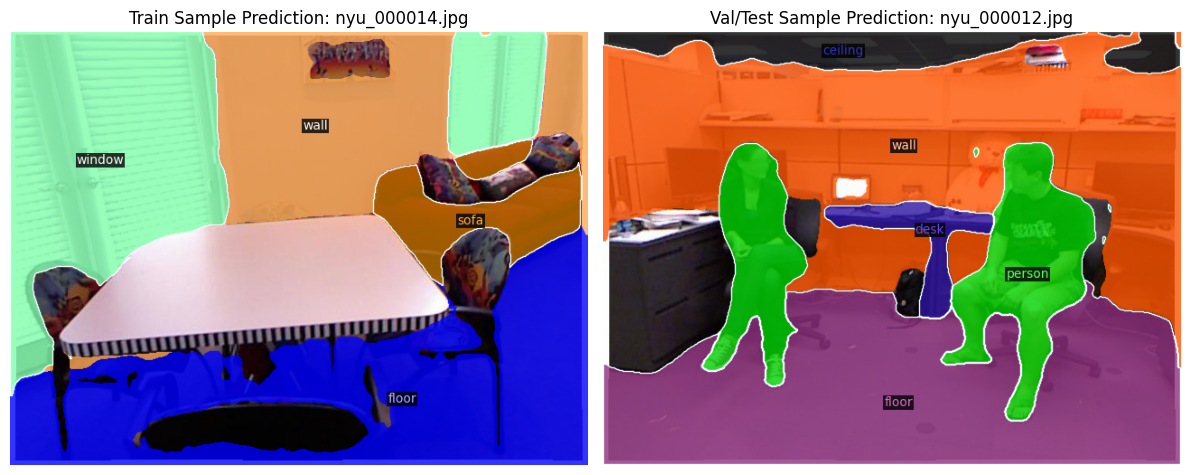

Saved artifact summary: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_swinb_ade20k_to_nyu_full/run_20260418_222910/training_artifacts.json
Done.


In [37]:
from detectron2.data import transforms as T
from detectron2.data import detection_utils as utils

# Use the in-memory model produced by the training cell (no checkpoint re-loading).
assert 'trainer' in globals() and getattr(trainer, 'model', None) is not None, (
    'trainer.model is not available in memory. Run Cell 14 (training cell) first.'
)

inference_model = trainer.model
inference_model.eval()

train_images = sorted(IMG_TR.glob('*.jpg'))
val_images = sorted(IMG_VA.glob('*.jpg'))
assert len(train_images) > 0, f'No train images found in {IMG_TR}'
assert len(val_images) > 0, f'No val/test images found in {IMG_VA}'

train_img_path = train_images[14]
val_img_path = val_images[12]

vis_out_dir = Path(cfg.OUTPUT_DIR) / 'val_predictions'
vis_out_dir.mkdir(parents=True, exist_ok=True)


def _get_class_names(metadata_name: str, num_classes_expected: int):
    classes = list(getattr(MetadataCatalog.get(metadata_name), 'stuff_classes', []))
    if len(classes) != int(num_classes_expected):
        classes = [f'class_{i}' for i in range(int(num_classes_expected))]
    return classes


def _build_semantic_confidence_table(sem_seg_probs: torch.Tensor, metadata_name: str):
    # sem_seg_probs shape: [C, H, W] from softmax over class channel.
    class_max = sem_seg_probs.amax(dim=(1, 2))
    class_mean = sem_seg_probs.mean(dim=(1, 2))
    pred = sem_seg_probs.argmax(dim=0)

    total_px = float(pred.numel())
    class_pixel_ratio = [float((pred == cid).sum().item() / total_px) for cid in range(sem_seg_probs.shape[0])]

    classes = _get_class_names(metadata_name, sem_seg_probs.shape[0])
    rows = []
    for cid in range(sem_seg_probs.shape[0]):
        rows.append({
            'class_id': int(cid),
            'class_name': classes[cid],
            'max_conf': float(class_max[cid].item()),
            'mean_conf': float(class_mean[cid].item()),
            'pixel_ratio': float(class_pixel_ratio[cid]),
        })
    rows.sort(key=lambda x: x['max_conf'], reverse=True)
    return rows


def _build_transformer_query_confidence_table(pred_logits: torch.Tensor, pred_masks: torch.Tensor, metadata_name: str):
    # pred_logits: [Q, C+1], pred_masks: [Q, H, W] from transformer heads.
    cls_probs = torch.softmax(pred_logits, dim=-1)[:, :-1]
    mask_probs = pred_masks.sigmoid()

    classes = _get_class_names(metadata_name, cls_probs.shape[1])
    query_mask_mean = mask_probs.mean(dim=(1, 2))

    best_query_prob = cls_probs.max(dim=0).values
    weighted_best = (cls_probs * query_mask_mean.unsqueeze(1)).max(dim=0).values
    mean_query_prob = cls_probs.mean(dim=0)

    rows = []
    for cid in range(cls_probs.shape[1]):
        rows.append({
            'class_id': int(cid),
            'class_name': classes[cid],
            'best_query_prob': float(best_query_prob[cid].item()),
            'weighted_best': float(weighted_best[cid].item()),
            'mean_query_prob': float(mean_query_prob[cid].item()),
        })
    rows.sort(key=lambda x: x['weighted_best'], reverse=True)
    return rows


def _print_top_semantic_confidences(title: str, rows, top_k: int = 12, min_max_conf: float = 0.01):
    keep = [r for r in rows if r['max_conf'] >= float(min_max_conf)]
    if not keep:
        print(f'[{title}] No semantic classes above max_conf >= {min_max_conf:.3f}')
        return
    print(f'[{title}] Semantic-map confidences (max_conf >= {min_max_conf:.3f})')
    print('  class_id | class_name               | max_conf | mean_conf | pixel_ratio')
    for r in keep[:top_k]:
        print(
            f"  {r['class_id']:>7d} | "
            f"{r['class_name'][:23]:<23} | "
            f"{r['max_conf']:.4f}   | "
            f"{r['mean_conf']:.4f}    | "
            f"{r['pixel_ratio']:.4f}"
        )


def _print_top_transformer_confidences(title: str, rows, top_k: int = 12, min_weighted: float = 0.01):
    keep = [r for r in rows if r['weighted_best'] >= float(min_weighted)]
    if not keep:
        print(f'[{title}] No transformer classes above weighted_best >= {min_weighted:.3f}')
        return
    print(f'[{title}] Transformer-query confidences (weighted_best >= {min_weighted:.3f})')
    print('  class_id | class_name               | best_query | weighted_best | mean_query')
    for r in keep[:top_k]:
        print(
            f"  {r['class_id']:>7d} | "
            f"{r['class_name'][:23]:<23} | "
            f"{r['best_query_prob']:.4f}     | "
            f"{r['weighted_best']:.4f}       | "
            f"{r['mean_query_prob']:.4f}"
        )


def _forward_transformer_heads(img_tensor_chw: torch.Tensor):
    # Direct access to transformer head outputs before Detectron2 post-processing.
    normed = (img_tensor_chw - inference_model.pixel_mean) / inference_model.pixel_std
    with torch.no_grad():
        feats = inference_model.backbone(normed.unsqueeze(0))
        head_out = inference_model.sem_seg_head(feats)
    pred_logits = head_out['pred_logits'][0]
    pred_masks = head_out['pred_masks'][0]
    return pred_logits, pred_masks


def predict_and_visualize(img_path: Path, metadata_name: str, conf_threshold: float = 0.6):
    # conf_threshold is applied on transformer query confidence (best_query_prob).
    img = utils.read_image(str(img_path), format=cfg.INPUT.FORMAT)
    h, w = img.shape[:2]

    aug = T.ResizeShortestEdge(
        [cfg.INPUT.MIN_SIZE_TEST, cfg.INPUT.MIN_SIZE_TEST],
        cfg.INPUT.MAX_SIZE_TEST,
        'choice',
    )
    img_resized = aug.get_transform(img).apply_image(img)
    img_tensor = torch.as_tensor(img_resized.astype('float32').transpose(2, 0, 1)).to(cfg.MODEL.DEVICE)

    with torch.no_grad():
        outputs = inference_model([{'image': img_tensor, 'height': h, 'width': w}])[0]

    pred_logits, pred_masks = _forward_transformer_heads(img_tensor)

    transformer_conf_table = _build_transformer_query_confidence_table(pred_logits, pred_masks, metadata_name)
    allowed_class_ids = [
        int(r['class_id']) for r in transformer_conf_table
        if float(r['best_query_prob']) >= float(conf_threshold)
    ]

    sem_seg_scores = outputs['sem_seg']
    sem_seg_probs = torch.softmax(sem_seg_scores, dim=0)
    sem_seg_pred = sem_seg_probs.argmax(dim=0)
    sem_seg = sem_seg_pred.to('cpu').numpy().astype(np.int32)

    ignore_label = int(getattr(MetadataCatalog.get(metadata_name), 'ignore_label', 255))
    if len(allowed_class_ids) == 0:
        sem_seg[:, :] = ignore_label
    else:
        keep_mask = np.isin(sem_seg, np.array(allowed_class_ids, dtype=np.int32))
        sem_seg[~keep_mask] = ignore_label

    sem_conf_table = _build_semantic_confidence_table(sem_seg_probs, metadata_name)

    v = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get(metadata_name), scale=1.0)
    vis = v.draw_sem_seg(sem_seg, area_threshold=0)
    out_img = vis.get_image()[:, :, ::-1]
    return img, out_img, sem_conf_table, transformer_conf_table


train_raw, train_pred, train_sem_conf, train_transformer_conf = predict_and_visualize(train_img_path, train_name, conf_threshold=0.9)
val_raw, val_pred, val_sem_conf, val_transformer_conf = predict_and_visualize(val_img_path, val_name, conf_threshold=0.9)

_print_top_semantic_confidences('Train sample', train_sem_conf, top_k=12, min_max_conf=0.01)
_print_top_transformer_confidences('Train sample', train_transformer_conf, top_k=12, min_weighted=0.01)
_print_top_semantic_confidences('Val sample', val_sem_conf, top_k=12, min_max_conf=0.01)
_print_top_transformer_confidences('Val sample', val_transformer_conf, top_k=12, min_weighted=0.01)

train_out_path = vis_out_dir / f'{train_img_path.stem}_train_pred.png'
val_out_path = vis_out_dir / f'{val_img_path.stem}_val_pred.png'
Image.fromarray(train_pred).save(train_out_path)
Image.fromarray(val_pred).save(val_out_path)
print('Saved train prediction:', train_out_path)
print('Saved val/test prediction:', val_out_path)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(train_pred)
plt.title(f'Train Sample Prediction: {train_img_path.name}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(val_pred)
plt.title(f'Val/Test Sample Prediction: {val_img_path.name}')
plt.axis('off')

plt.tight_layout()
plt.show()

artifact = {
    'config_file': str(config_file),
    'weights_init': cfg.MODEL.WEIGHTS,
    'weights_final': 'in-memory trainer.model (no reload)',
    'output_dir': str(cfg.OUTPUT_DIR),
    'train_dataset': train_name,
    'val_dataset': val_name,
    'num_classes': num_classes,
    'ims_per_batch': cfg.SOLVER.IMS_PER_BATCH,
    'max_iter': cfg.SOLVER.MAX_ITER,
    'eval_period': cfg.TEST.EVAL_PERIOD,
    'checkpoint_period': cfg.SOLVER.CHECKPOINT_PERIOD,
    'num_train_samples': len(train_images),
    'num_val_samples': len(val_images),
    'train_preview_image': str(train_out_path),
    'val_preview_image': str(val_out_path),
}
artifact_path = Path(cfg.OUTPUT_DIR) / 'training_artifacts.json'
with open(artifact_path, 'w') as f:
    json.dump(artifact, f, indent=2)

print('Saved artifact summary:', artifact_path)
print('Done.')

[External sample] Semantic-map confidences (max_conf >= 0.030)
  class_id | class_name               | max_conf | mean_conf | pixel_ratio
        8 | window                  | 0.0713   | 0.0287    | 0.1228
        0 | wall                    | 0.0652   | 0.0452    | 0.5377
        3 | bed                     | 0.0651   | 0.0312    | 0.2061
       17 | pillow                  | 0.0646   | 0.0267    | 0.0748
        1 | floor                   | 0.0635   | 0.0249    | 0.0262
       15 | curtain                 | 0.0555   | 0.0271    | 0.0078
       12 | blinds                  | 0.0488   | 0.0264    | 0.0000
       18 | mirror                  | 0.0356   | 0.0243    | 0.0001
[External sample] Transformer-query confidences (weighted_best >= 0.010)
  class_id | class_name               | best_query | weighted_best | mean_query
        0 | wall                    | 0.9999     | 0.5076       | 0.0100
        3 | bed                     | 0.9999     | 0.2013       | 0.0101
        8 | window 

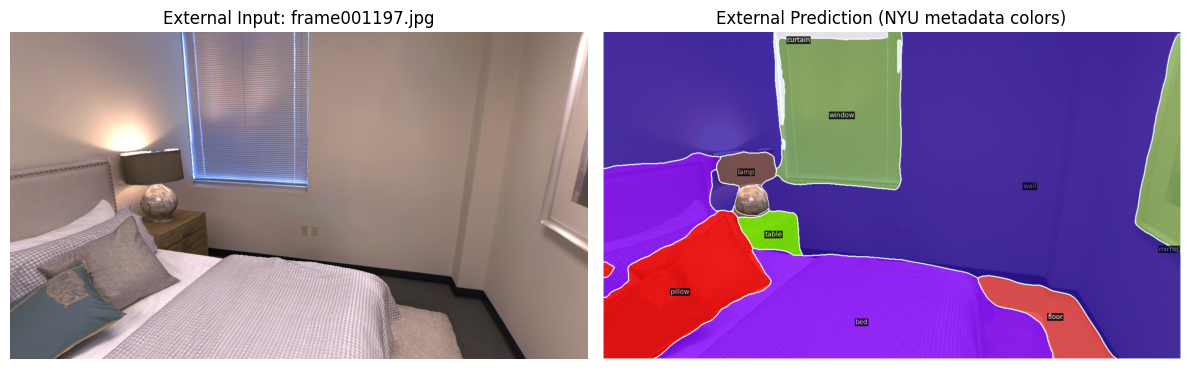

In [45]:
# 11) External image inference (Replica frame outside train/val split)
replica_image_path = Path('/home/abdou/Projects/Python/RTSGS/Datasets/Replica/ThirdParty/Replica/room1/results/frame001197.jpg')
assert replica_image_path.exists(), f'External image not found: {replica_image_path}'

# Reuse the same in-memory model and prediction flow as Cell 16.
assert 'trainer' in globals() and getattr(trainer, 'model', None) is not None, (
    'trainer.model is not available in memory. Run Cell 14 first.'
)
inference_model = trainer.model
inference_model.eval()

assert 'predict_and_visualize' in globals(), (
    'predict_and_visualize() not found. Run Cell 16 first to define it.'
)

external_raw, external_pred, external_sem_conf, external_transformer_conf = predict_and_visualize(replica_image_path, val_name, 0.05)
_print_top_semantic_confidences('External sample', external_sem_conf, top_k=12, min_max_conf=0.03)
_print_top_transformer_confidences('External sample', external_transformer_conf, top_k=12, min_weighted=0.01)

external_out_dir = Path(cfg.OUTPUT_DIR) / 'val_predictions'
external_out_dir.mkdir(parents=True, exist_ok=True)
external_out_path = external_out_dir / f'{replica_image_path.stem}_external_pred.png'
Image.fromarray(external_pred).save(external_out_path)

print('External input image:', replica_image_path)
print('Saved external prediction:', external_out_path)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(external_raw)
plt.title(f'External Input: {replica_image_path.name}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(external_pred)
plt.title('External Prediction (NYU metadata colors)')
plt.axis('off')

plt.tight_layout()
plt.show()